<h1 style="text-align: center;">Assessment 2 Part A: PRML Project (Stage 3/3) - Journey's End</h1>
<h2 style="text-align: center;">Pattern Recognition and Machine Learning</h2> 
<h3 style="text-align: center;">By Ruhan Shafi | u3284342</h3>

PLEASE DO NOT CLICK "Run All" if there is a folder called "HAM10000_images", as it will cause errors, ensure that all files apart from this notebook/`README.md` are removed prior to running the download commands

## Importing Libraries

In [1]:
import os
import datetime
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras import mixed_precision
import keras_tuner as kt
import shutil
import zipfile
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

# Enable mixed precision for faster training and reduced memory usage
mixed_precision.set_global_policy("mixed_float16")

# Adjust threading for CPU (optional)
try:
    tf.config.threading.set_intra_op_parallelism_threads(0)
    tf.config.threading.set_inter_op_parallelism_threads(0)
except RuntimeError:
    print("⚠️ Threads must be set before TensorFlow runtime initialization.")

#AUTOTUNE = tf.data.AUTOTUNE

## Downloading the Dataset via Kaggle CLI
Please ensure that your Kaggle CLI environment is properly configurated prior to running this command. Please check Kaggle API documentation to find out to configure the Kaggle CLI for your enviroment. Once it has been properly configured, uncomment the second line and run this command. (This has been commented so prevent accidental downloads as this takes up allocated API useage and to save on time and storage)

In [3]:
!kaggle datasets download kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0




  0%|          | 0.00/5.20G [00:00<?, ?B/s]
  0%|          | 1.00M/5.20G [00:02<3:11:08, 487kB/s]
  0%|          | 2.00M/5.20G [00:02<1:50:55, 838kB/s]
  1%|          | 46.0M/5.20G [00:03<04:09, 22.2MB/s] 
  2%|▏         | 115M/5.20G [00:03<01:35, 57.0MB/s] 
  2%|▏         | 125M/5.20G [00:06<04:07, 22.0MB/s]
  4%|▍         | 214M/5.20G [00:06<01:41, 52.7MB/s]
  4%|▍         | 237M/5.20G [00:06<01:27, 61.2MB/s]
  5%|▍         | 257M/5.20G [00:12<05:41, 15.6MB/s]
  5%|▌         | 271M/5.20G [00:12<05:07, 17.2MB/s]
  7%|▋         | 359M/5.20G [00:12<02:08, 40.5MB/s]
  7%|▋         | 394M/5.20G [00:13<02:11, 39.2MB/s]
  8%|▊         | 419M/5.20G [00:20<06:15, 13.7MB/s]
  8%|▊         | 437M/5.20G [00:21<05:29, 15.5MB/s]
 10%|▉         | 516M/5.20G [00:21<02:38, 31.7MB/s]
 10%|█         | 549M/5.20G [00:21<02:16, 36.6MB/s]
 12%|█▏        | 636M/5.20G [00:21<01:13, 66.8MB/s]
 13%|█▎        | 680M/5.20G [00:21<00:58, 83.8MB/s]
 14%|█▍        | 770M/5.20G [00:22<00:34, 137MB/s] 
 16%|█▌     

## Extracting zip file and placing the spilt images backinto one folder

In [8]:
base_dir = os.getcwd()
zip_path = os.path.join(base_dir, "skin-cancer-mnist-ham10000.zip")

# Extract zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(base_dir)

# Output unified folder
img_dir = os.path.join(base_dir, "HAM10000_images")
os.makedirs(img_dir, exist_ok=True)

# Find all part folders (case-insensitive)
part_folders = glob.glob(os.path.join(base_dir, "*part*"))

# Move images into HAM10000_images
for folder in part_folders:
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            src = os.path.join(folder, file)
            dst = os.path.join(img_dir, file)
            shutil.move(src, dst)
        print(f"✅ Moved images from {os.path.basename(folder)}")
        shutil.rmtree(folder)  # delete folder after moving

print("✅ All images unified in:", img_dir)
print("Number of images:", len(os.listdir(img_dir)))

✅ Moved images from HAM10000_images_part_1
✅ Moved images from HAM10000_images_part_2
✅ All images unified in: d:\User Data\Ruhan's Data\Documents\Code\HAM10000-CNN-SVM\HAM10000_images
Number of images: 10015


## Spilting the dataset

In [16]:
# -------------------------
# Paths (everything in current folder)
# -------------------------
base_dir = os.getcwd()
img_dir = os.path.join(base_dir, "HAM10000_images")
metadata_path = os.path.join(base_dir, "HAM10000_metadata.csv")

# Output folders
train_dir = os.path.join(base_dir, "train_images")
test_dir = os.path.join(base_dir, "test_images")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# -------------------------
# Load metadata
# -------------------------
df = pd.read_csv(metadata_path)

print("✅ Metadata loaded.")
print("Number of rows:", len(df))
print("Unique classes:", df["dx"].unique())

# -------------------------
# Train/test split (80/20 stratified on dx)
# -------------------------
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["dx"],
    random_state=42
)

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

# Save metadata CSVs
train_metadata_path = os.path.join(base_dir, "train_metadata.csv")
test_metadata_path = os.path.join(base_dir, "test_metadata.csv")

train_df.to_csv(train_metadata_path, index=False)
test_df.to_csv(test_metadata_path, index=False)

print(f"✅ Saved: train_metadata.csv")
print(f"✅ Saved: test_metadata.csv")

# -------------------------
# Copy images into split folders
# -------------------------
def copy_images(df, target_dir):
    copied, missing = 0, []
    for img_id in df["image_id"]:
        src = os.path.join(img_dir, img_id + ".jpg")
        dst = os.path.join(target_dir, img_id + ".jpg")
        if os.path.exists(src):
            shutil.copy(src, dst)
            copied += 1
        else:
            missing.append(img_id)
    print(f"📂 Copied {copied} images → {os.path.basename(target_dir)}")
    if missing:
        print(f"⚠️ Missing {len(missing)} images. Example: {missing[:10]}")

copy_images(train_df, train_dir)
copy_images(test_df, test_dir)

print("🎉 Dataset split complete.")


✅ Metadata loaded.
Number of rows: 10015
Unique classes: ['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']
Train size: 8012, Test size: 2003
✅ Saved: train_metadata.csv
✅ Saved: test_metadata.csv
📂 Copied 8012 images → train_images
📂 Copied 2003 images → test_images
🎉 Dataset split complete.


## Moves and Sorts images into folders by `dx` type

In [2]:


# -------------------------
# Paths - Variables are redecaleed here so you don't have to run the unzip cell which unzips regardless of if the file was previously unzipped
# -------------------------
base_dir = os.getcwd()
train_dir = os.path.join(base_dir, "train_images")
test_dir = os.path.join(base_dir, "test_images")
train_csv = os.path.join(base_dir, "train_metadata.csv")
test_csv = os.path.join(base_dir, "test_metadata.csv")

# -------------------------
# Load metadata
# -------------------------
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

# -------------------------
# Function to reorganize images into class subfolders
# -------------------------
def reorganize_images(df, img_dir):
    """
    Moves images into class subfolders based on 'dx' column.
    """
    for _, row in df.iterrows():
        class_folder = os.path.join(img_dir, row['dx'])
        os.makedirs(class_folder, exist_ok=True)  # create class folder if missing
        src = os.path.join(img_dir, row['image_id'] + ".jpg")
        dst = os.path.join(class_folder, row['image_id'] + ".jpg")
        # Move image only if it is in the root of img_dir
        if os.path.exists(src):
            shutil.move(src, dst)

# Reorganize train and test images
reorganize_images(train_df, train_dir)
reorganize_images(test_df, test_dir)

print("✅ Images reorganized into class subfolders for TensorFlow.")



✅ Images reorganized into class subfolders for TensorFlow.


C:\Users\ruhanshafi\AppData\Local\Temp\ipykernel_14864\1731534176.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="dx", data=metadata, order=metadata["dx"].value_counts().index, palette="Set2")


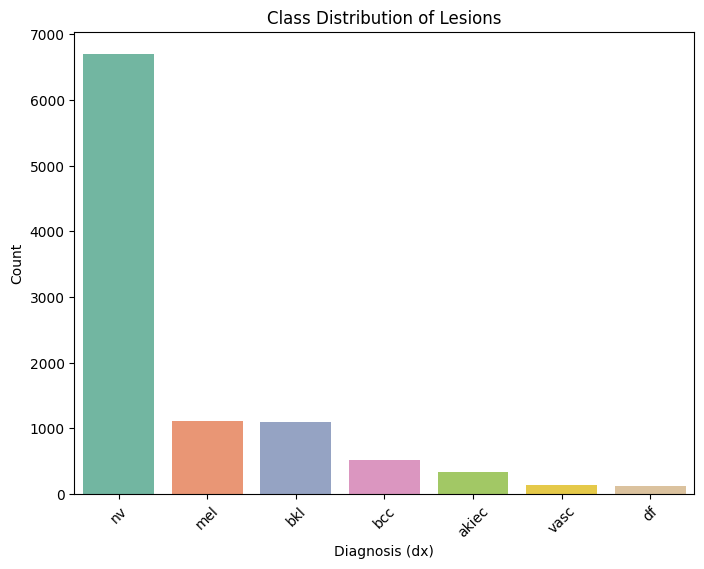

C:\Users\ruhanshafi\AppData\Local\Temp\ipykernel_14864\1731534176.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="dx", y="age", data=metadata, palette="Set3")


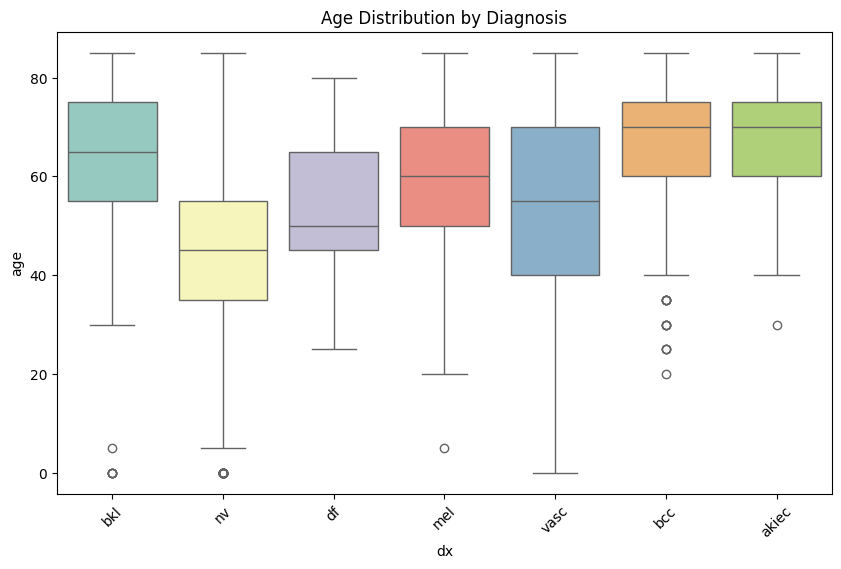

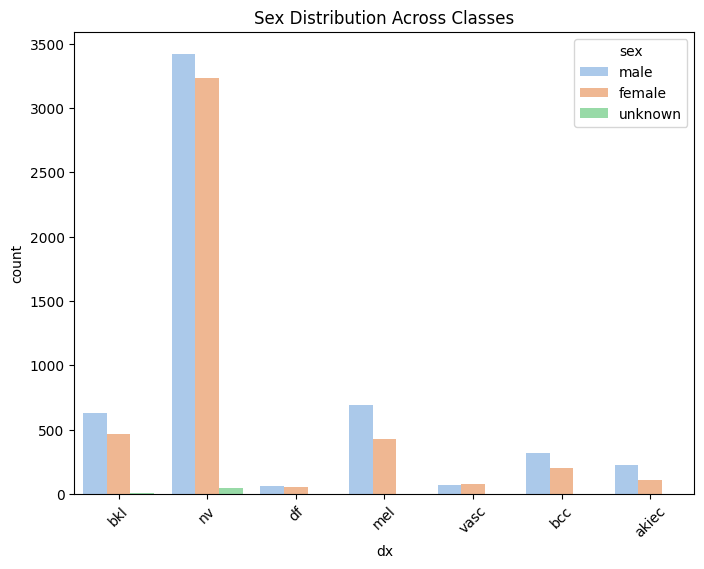

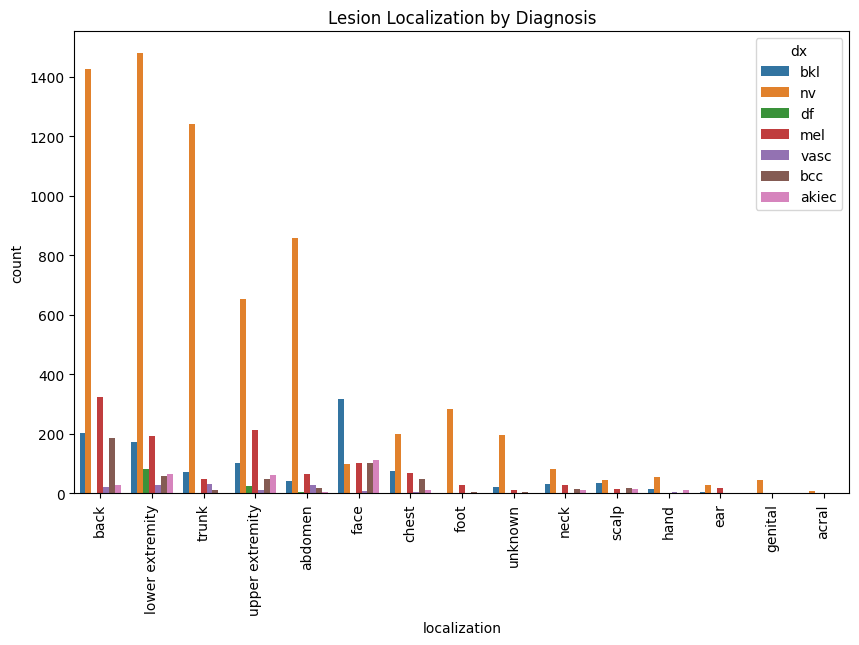

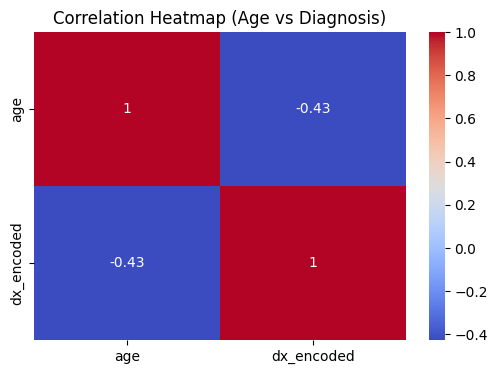

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# Load metadata
# -------------------------
metadata = pd.read_csv("HAM10000_metadata.csv")

# -------------------------
# Class distribution
# -------------------------
plt.figure(figsize=(8,6))
sns.countplot(x="dx", data=metadata, order=metadata["dx"].value_counts().index, palette="Set2")
plt.title("Class Distribution of Lesions")
plt.xlabel("Diagnosis (dx)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# Age distribution per class
# -------------------------
plt.figure(figsize=(10,6))
sns.boxplot(x="dx", y="age", data=metadata, palette="Set3")
plt.title("Age Distribution by Diagnosis")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# Sex distribution per class
# -------------------------
plt.figure(figsize=(8,6))
sns.countplot(x="dx", hue="sex", data=metadata, palette="pastel")
plt.title("Sex Distribution Across Classes")
plt.xticks(rotation=45)
plt.show()

# -------------------------
# Localization distribution
# -------------------------
plt.figure(figsize=(10,6))
sns.countplot(x="localization", hue="dx", data=metadata, order=metadata["localization"].value_counts().index)
plt.title("Lesion Localization by Diagnosis")
plt.xticks(rotation=90)
plt.show()

# -------------------------
# Correlation heatmap (numeric features only)
# -------------------------
numeric_features = metadata[["age"]].copy()
numeric_features["dx_encoded"] = metadata["dx"].astype("category").cat.codes  # encode dx as numbers

corr = numeric_features.corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Age vs Diagnosis)")
plt.show()


## Loading Data into the TensorFlow Enviornment

In [3]:

base_dir = os.getcwd()
train_dir = os.path.join(base_dir, "train_images")
test_dir  = os.path.join(base_dir, "test_images")

img_height = 128
img_width = 128
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

train_tensorflow = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

test_tensorflow = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)
# Save class names BEFORE any dataset transformations
class_names = train_tensorflow.class_names
num_classes = len(class_names)
print("✅ Classes:", class_names)

Found 8012 files belonging to 7 classes.
Found 2003 files belonging to 7 classes.
✅ Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## Creating the Normalization and Data Augmentation Layers

This section of code is responsible for the following; scaling the RGB channel values for each pixel from `[0,255]` to `[0,1]`. This makes training the model easier since the matrix multiplication calucations returns far easier numbers to work with and creating a data augmentation layer implemented through the use of TensorFlow’s built-in function and included random flipping, rotation, and zooming to expand the dataset and improve model generalisation artificially.

In [4]:
normalization_layer = layers.Rescaling(1./255)

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

train_prepared = (
    train_tensorflow
    .map(lambda x, y: (normalization_layer(data_augmentation(x)), y))
    .cache()
    .shuffle(500)
    .prefetch(buffer_size=AUTOTUNE)
)

test_prepared = (
    test_tensorflow
    .map(lambda x, y: (normalization_layer(x), y))
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

c:\Users\ruhanshafi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Hyprparameters tuning using Keras Tuner

In [5]:
base_logdir = "logs/tensorboard_tuning"
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = os.path.join(base_logdir, timestamp)
os.makedirs(log_dir, exist_ok=True)

HP_LEARNING_RATE = kt.HyperParameters()
HP_LEARNING_RATE.Choice("learning_rate", [1e-3, 1e-4])  # Reduced tuning
HP_DENSE_UNITS = kt.HyperParameters()
HP_DENSE_UNITS.Choice("dense_units", [64, 128])
HP_DROPOUT = kt.HyperParameters()
HP_DROPOUT.Choice("dropout_rate", [0.3, 0.4])

0.3

### Configuration of CNN Layers and which hyprparameters to tune for

In [6]:
def build_cnn_model(hp):
    model = models.Sequential([
        layers.Conv2D(
            filters=hp.Choice("filters_1", [32, 64, 96]),
            kernel_size=3,
            activation="relu",
            input_shape=(img_height, img_width, 3)
        ),
        layers.MaxPooling2D(),
        layers.Conv2D(
            filters=hp.Choice("filters_2", [64, 128, 160]),
            kernel_size=3,
            activation="relu"
        ),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(
            hp.Choice("dense_units", [128, 192, 256]), 
            activation="relu"
        ),
        layers.Dropout(hp.Float("dropout", 0.3, 0.5, step=0.1)),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice("learning_rate", [1e-3, 5e-4, 1e-4])
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


### Configuration of MLP layers and which hyprparameters to tune for

In [7]:
def build_mlp_model(hp):
    model = models.Sequential([
        layers.Flatten(input_shape=(img_height, img_width, 3)),
        layers.Dense(
            hp.Choice("dense1_units", [256, 384, 512]), 
            activation="relu"
        ),
        layers.Dropout(hp.Float("dropout1", 0.3, 0.5, step=0.1)),
        layers.Dense(
            hp.Choice("dense2_units", [128, 192, 256]), 
            activation="relu"
        ),
        layers.Dropout(hp.Float("dropout2", 0.3, 0.5, step=0.1)),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice("learning_rate", [1e-3, 5e-4, 1e-4])
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


### Kears Tuner

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
import keras_tuner as kt
import os, datetime

base_logdir = "logs/tensorboard_tuning"
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = os.path.join(base_logdir, timestamp)
os.makedirs(log_dir, exist_ok=True)

def tune_model(model_builder, model_name, max_trials=12, executions_per_trial=1, search_epochs=6, final_epochs=10):
    tuner_logdir = os.path.join(log_dir, f"{model_name}_tuner")

    tuner = kt.BayesianOptimization(
        model_builder,
        objective="val_accuracy",
        max_trials=max_trials,
        executions_per_trial=executions_per_trial,
        directory=tuner_logdir,
        project_name=model_name
    )

    stop_early = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
    )

    # -------------------------
    # Search Phase
    # -------------------------
    tuner.search(
        train_prepared,
        validation_data=test_prepared,
        epochs=search_epochs,
        callbacks=[stop_early, lr_scheduler, TensorBoard(log_dir=tuner_logdir)]
    )

    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"\n🏆 Best Hyperparameters for {model_name}:")
    for param, value in best_hps.values.items():
        print(f"  - {param}: {value}")

    best_model = tuner.hypermodel.build(best_hps)

    # -------------------------
    # Train Final Model
    # -------------------------
    history = best_model.fit(
        train_prepared,
        validation_data=test_prepared,
        epochs=final_epochs,
        callbacks=[
            stop_early,
            lr_scheduler,
            ModelCheckpoint(filepath=f"{model_name}_best.keras", save_best_only=True),
            TensorBoard(log_dir=tuner_logdir)
        ]
    )

    test_loss, test_acc = best_model.evaluate(test_prepared)
    print(f"\n✅ {model_name} Test Accuracy: {test_acc:.4f}")

    return best_model, history

### Finding best CNN parameters

In [11]:
cnn_model, cnn_history = tune_model(build_cnn_model, "CNN_Model")

Trial 12 Complete [00h 03m 41s]
val_accuracy: 0.7259111404418945

Best val_accuracy So Far: 0.7324013710021973
Total elapsed time: 01h 59m 32s

🏆 Best Hyperparameters for CNN_Model:
  - filters_1: 64
  - filters_2: 160
  - dense_units: 256
  - dropout: 0.3
  - learning_rate: 0.0005
Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 138s 544ms/step - accuracy: 0.6618 - loss: 1.0743 - val_accuracy: 0.6680 - val_loss: 1.0758 - learning_rate: 5.0000e-04
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 130s 520ms/step - accuracy: 0.6694 - loss: 0.9002 - val_accuracy: 0.6785 - val_loss: 0.9444 - learning_rate: 5.0000e-04
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 130s 518ms/step - accuracy: 0.6917 - loss: 0.8258 - val_accuracy: 0.6990 - val_loss: 0.7949 - learning_rate: 5.0000e-04
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 584ms/step - accuracy: 0.7068 - loss: 0.7876 - val_accuracy: 0.7129 - val_loss: 0.7878 - learning_rate: 5.0000e-04
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 124s 495ms/step - accuracy: 0.7219 - 

### Finding best MLP parameters

In [12]:
mlp_model, mlp_history = tune_model(build_mlp_model, "MLP_Model")

Trial 12 Complete [00h 01m 59s]
val_accuracy: 0.6694957613945007

Best val_accuracy So Far: 0.6694957613945007
Total elapsed time: 00h 37m 42s

🏆 Best Hyperparameters for MLP_Model:
  - dense1_units: 256
  - dropout1: 0.4
  - dense2_units: 256
  - dropout2: 0.3
  - learning_rate: 0.0005
Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.6317 - loss: 1.9620 - val_accuracy: 0.6695 - val_loss: 1.2701 - learning_rate: 5.0000e-04
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - accuracy: 0.6684 - loss: 1.1760 - val_accuracy: 0.6695 - val_loss: 1.1538 - learning_rate: 5.0000e-04
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - accuracy: 0.6695 - loss: 1.1556 - val_accuracy: 0.6695 - val_loss: 1.1343 - learning_rate: 5.0000e-04
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 29s 114ms/step - accuracy: 0.6695 - loss: 1.1366 - val_accuracy: 0.6695 - val_loss: 1.1313 - learning_rate: 5.0000e-04
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step - accuracy: 0.6695 - 

## Finding best Parameters

In [13]:
cnn_acc = max(cnn_history.history["val_accuracy"])
mlp_acc = max(mlp_history.history["val_accuracy"])

if cnn_acc > mlp_acc:
    best_model, best_history, best_name = cnn_model, cnn_history, "CNN"
else:
    best_model, best_history, best_name = mlp_model, mlp_history, "MLP"

print(f"\n🏆 Final Selected Model: {best_name} (Val Accuracy = {max(best_history.history['val_accuracy']):.4f})")


🏆 Final Selected Model: CNN (Val Accuracy = 0.7359)


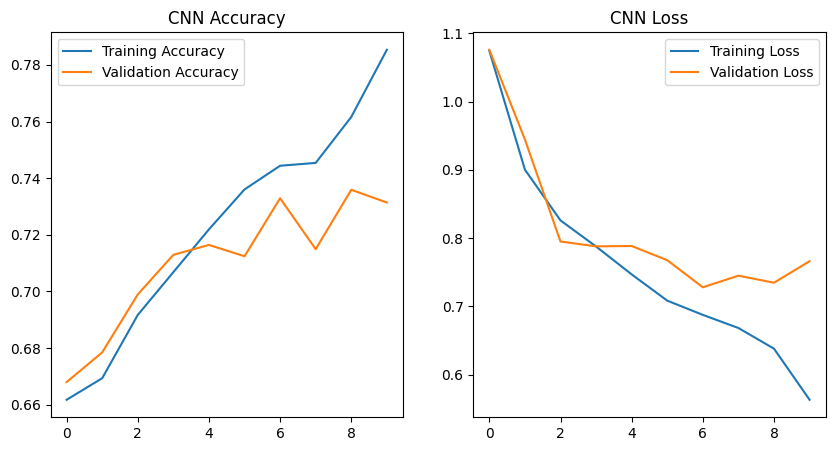

In [14]:
acc = best_history.history["accuracy"]
val_acc = best_history.history["val_accuracy"]
loss = best_history.history["loss"]
val_loss = best_history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title(f"{best_name} Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title(f"{best_name} Loss")
plt.show()

## Training Final Model / Evaluation on Unseen Data

In [15]:
print(f"\nFinal Evaluation on Test Set for {best_name}:")
test_loss, test_acc = best_model.evaluate(test_prepared)
print(f"Test Accuracy: {test_acc:.4f}")


Final Evaluation on Test Set for CNN:
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.7329 - loss: 0.7278
Test Accuracy: 0.7329


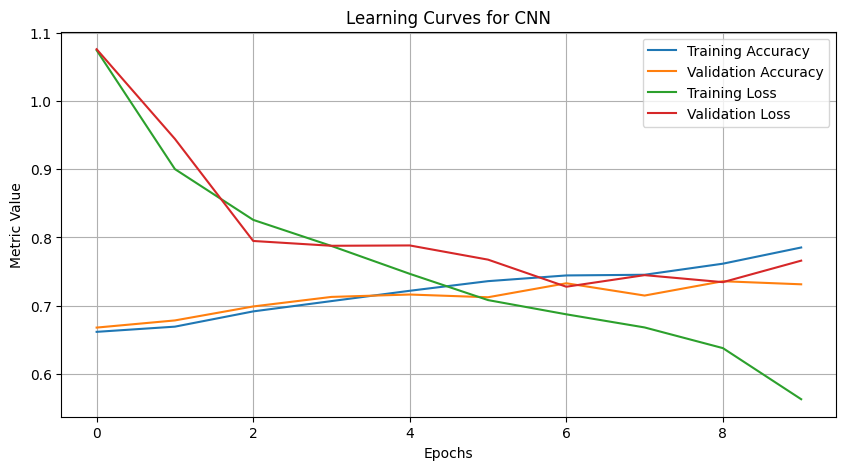

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step


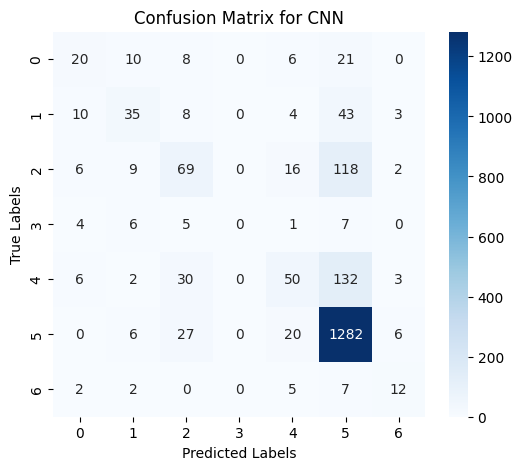

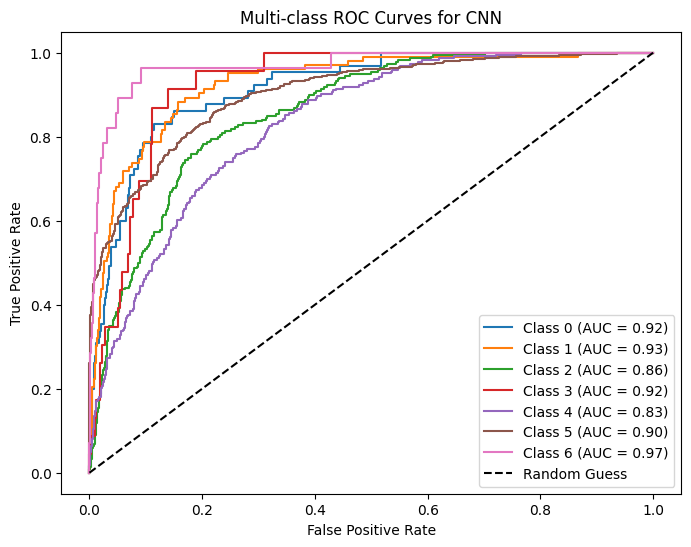


Classification Report on Unseen Data:
              precision    recall  f1-score   support

       akiec       0.42      0.31      0.35        65
         bcc       0.50      0.34      0.40       103
         bkl       0.47      0.31      0.38       220
          df       0.00      0.00      0.00        23
         mel       0.49      0.22      0.31       223
          nv       0.80      0.96      0.87      1341
        vasc       0.46      0.43      0.44        28

    accuracy                           0.73      2003
   macro avg       0.45      0.37      0.39      2003
weighted avg       0.68      0.73      0.70      2003



c:\Users\ruhanshafi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ruhanshafi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ruhanshafi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import numpy as np

# 1️⃣ Learning Curves
plt.figure(figsize=(10,5))
plt.plot(best_history.history['accuracy'], label='Training Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title(f'Learning Curves for {best_name}')
plt.xlabel('Epochs')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.show()

# 2️⃣ Confusion Matrix
# Obtain predictions on the test set
y_true = np.concatenate([y for x, y in test_prepared], axis=0)
y_pred_probs = best_model.predict(test_prepared)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_true, axis=1)

cm = confusion_matrix(y_true_labels, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f'Confusion Matrix for {best_name}')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# 3️⃣ ROC Curve (for multi-class classification)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarize true labels for multi-class ROC
y_true_bin = label_binarize(y_true_labels, classes=range(y_pred_probs.shape[1]))
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8,6))
for i in range(y_pred_probs.shape[1]):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.title(f'Multi-class ROC Curves for {best_name}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report on Unseen Data:")
print(classification_report(y_true_labels, y_pred, target_names=class_names))

## Saving the Model

In [ ]:
best_model.save("final_cnn_model.h5")

# Can be loaded back into Tensorflow by the following command
#model = tf.keras.models.load_model("final_cnn_model.h5")
